# Housing Price Prediction Using Linear Regression  
**Author: May Cooper**

## Project Overview  
This notebook applies supervised learning techniques—specifically Ordinary Least Squares (OLS) regression—to model and predict residential housing prices. The dataset includes both property-specific features (e.g., square footage, number of bedrooms and bathrooms, backyard space) and neighborhood-level characteristics (e.g., crime rate, school rating, distance to city center).

## Research Question  
How do structural property attributes and neighborhood factors influence residential house prices?

## Objective  
The objective of this analysis is to identify the most influential predictors of housing prices and develop a statistically sound, interpretable regression model. The insights are intended to support real estate developers, homebuyers, and investors in making informed, data-driven decisions.

## Data Prep

In [ ]:
# Imports and Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Loading the dataset
file_path = ''
data = pd.read_csv(file_path)

# Displaying first few rows
data.head()


,ID,Price,SquareFootage,NumBathrooms,NumBedrooms,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,...,RenovationQuality,LocalAmenities,TransportAccess,Fireplace,HouseColor,Garage,Floors,Windows,PreviousSalePrice,IsLuxury
0,4922,255614.8992,566.62,1.000000,4,779.42,20.56,5.62,39.46,10.08,...,4.93,4.44,4.55,Yes,Blue,No,1,13,181861.54230,0
1,5009,155586.0947,1472.34,1.000000,2,656.13,15.62,5.63,40.51,7.89,...,4.08,5.56,6.83,No,Green,No,1,17,50042.59757,0
2,4450,131050.8324,550.00,1.779354,3,754.57,12.47,9.20,48.38,23.74,...,4.26,8.07,8.48,Yes,Green,Yes,2,34,48400.34440,0
3,1070,151361.7125,941.81,2.035254,2,439.59,22.22,7.08,94.67,5.22,...,4.45,5.00,6.27,Yes,Red,No,1,14,84594.12145,0
4,400,113167.6128,550.00,1.064644,3,353.03,8.28,5.93,16.80,43.13,...,3.36,5.46,6.99,No,White,Yes,1,21,22934.59654,0


### Identify the Dependent and Independent Variables

#### **Dependent Variable**
- **`Price`**: The target variable that represents the house price. This is the primary variable of interest in the analysis, as the goal is to understand which factors influence house prices.

#### **Independent Variables**
1. **`SquareFootage`**: The size of the house in square feet, which impacts the price of a property.
2. **`NumBedrooms`**: The number of bedrooms in a house, as more bedrooms usually increase the house's value.
3. **`NumBathrooms`**: The number of bathrooms, which direclty impacts desirability and the house's practicality. 
4. **`BackyardSpace`**: The size of the backyard, which strengthens the overall property value.
5. **`CrimeRate`**: The crime rate in the neighborhood. Higher crime rates tend to lower property desirability and prices.
6. **`SchoolRating`**: The rating of nearby schools, as better schools typically drive up demand and house prices.
7. **`DistanceToCityCenter`**: The distance to the city center, which affects convenience and thus impacts house prices.

#### **Justification for Selection**
These variables were selected because they logically impact house prices:
- **Property-Specific Factors**: Variables like ___square footage___, ___number of bedrooms/bathrooms___, and ___backyard size___ directly relate to the physical attributes of the property.
- **Location-Related Factors**: Variables like ___crime rate___, ___school rating___, and ___proximity to the city center___ capture the influence of external factors on desirability and value of the house.

This combination of variables ensures a comprehensive analysis that considers both internal and external factors affecting house prices.

In [ ]:
# Identify the dependent and independent variables
dependent_variable = 'Price'
independent_variables = ['SquareFootage', 'NumBedrooms', 'NumBathrooms',
                         'BackyardSpace', 'CrimeRate', 'SchoolRating',
                         'DistanceToCityCenter']

In [ ]:
# Describe the dependent variable and all independent variables
# This includes counts, means, standard deviations, ranges, and min/max values
data[[dependent_variable] + independent_variables].describe()

,Price,SquareFootage,NumBedrooms,NumBathrooms,BackyardSpace,CrimeRate,SchoolRating,DistanceToCityCenter
count,7.000000e+03,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,3.072820e+05,1048.947459,3.008571,2.131397,511.507029,31.226194,6.942923,17.475337
std,1.501734e+05,426.010482,1.021940,0.952561,279.926549,18.025327,1.888148,12.024985
min,8.500000e+04,550.000000,1.000000,1.000000,0.390000,0.030000,0.220000,0.000000
25%,1.921075e+05,660.815000,2.000000,1.290539,300.995000,17.390000,5.650000,7.827500
50%,2.793230e+05,996.320000,3.000000,1.997774,495.965000,30.385000,7.010000,15.625000
75%,3.918781e+05,1342.292500,4.000000,2.763997,704.012500,43.670000,8.360000,25.222500
max,1.046676e+06,2874.700000,7.000000,5.807239,1631.360000,99.730000,10.000000,65.200000


In [ ]:
# Describe the Dependent and Independent Variables
# Calculating mode for dependent and independent variables since mode is not included in describe() stats
modes = data[[dependent_variable] + independent_variables].mode().iloc[0]

# Converting the mode data into a table-friendly format
mode_table = pd.DataFrame({
    "Variable": [dependent_variable] + independent_variables,
    "Mode": modes.values
})

# Displaying table with pandas
mode_table.style.set_caption("Mode of Dependent and Independent Variables").set_table_styles(
    [{'selector': 'caption', 'props': [('font-size', '16px'), ('text-align', 'center')]}]
).hide(axis='index').format(precision=2)


Variable,Mode
Price,85000.00
SquareFootage,550.00
NumBedrooms,3.00
NumBathrooms,1.00
BackyardSpace,300.08
CrimeRate,34.01
SchoolRating,10.00
DistanceToCityCenter,8.29


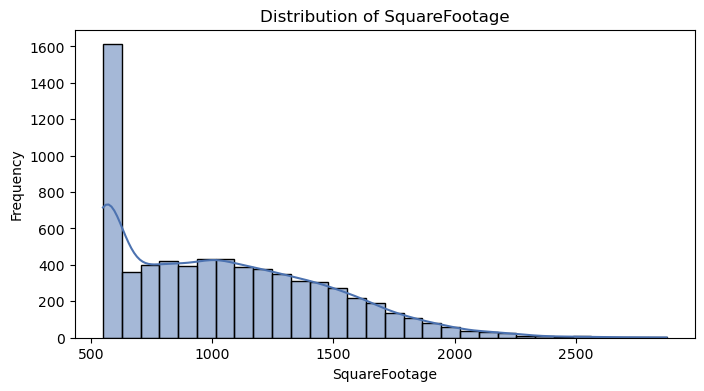

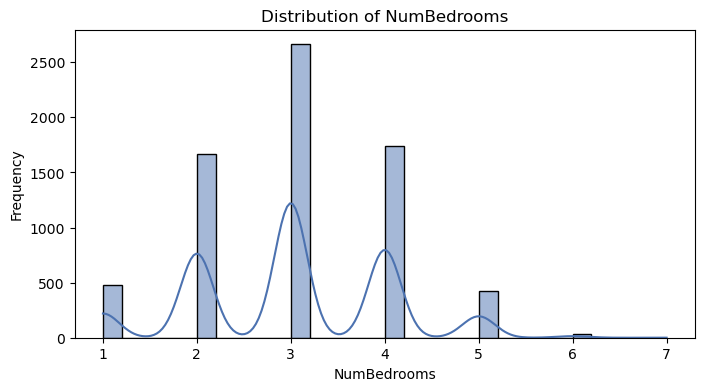

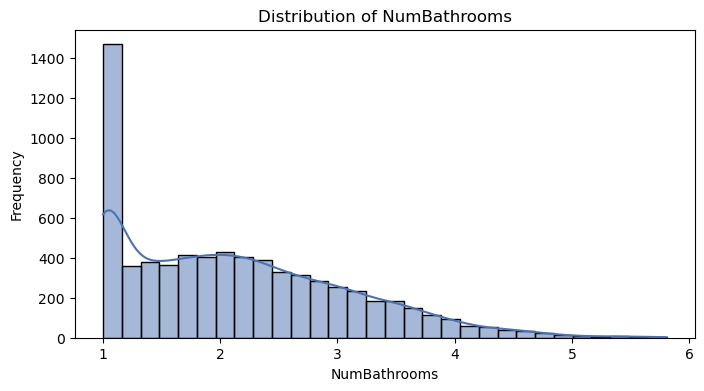

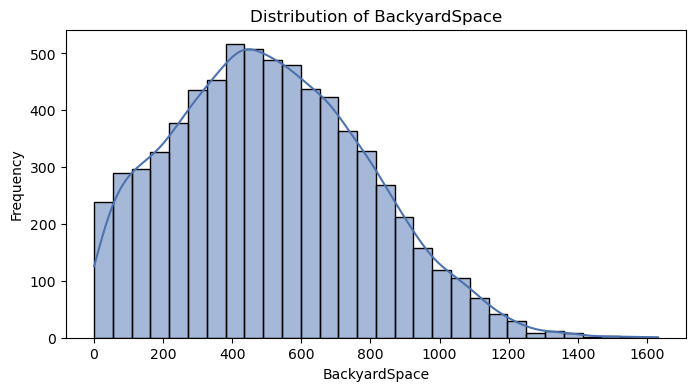

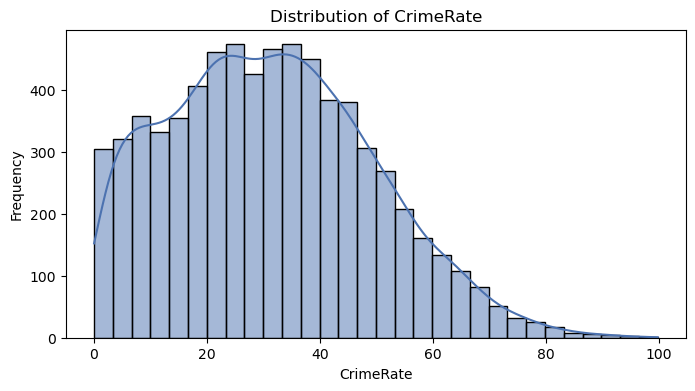

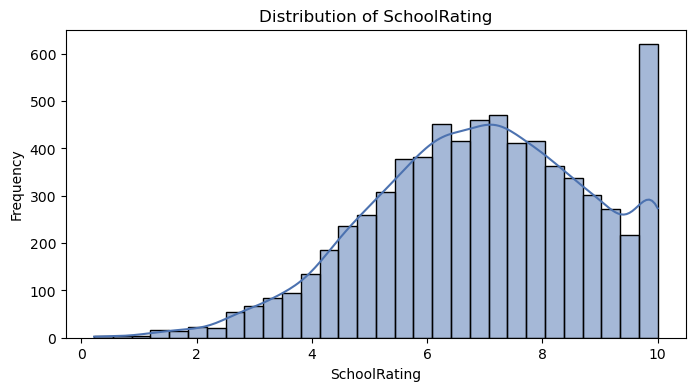

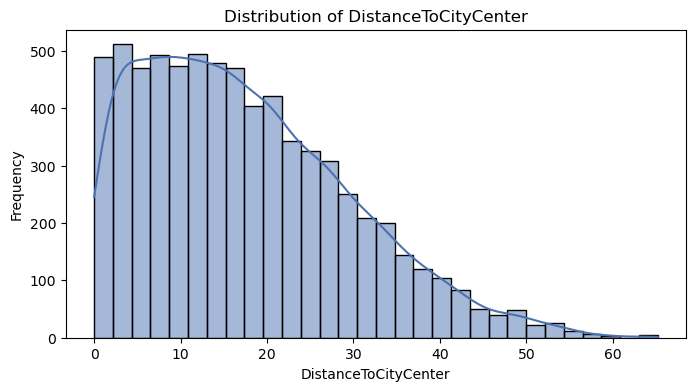

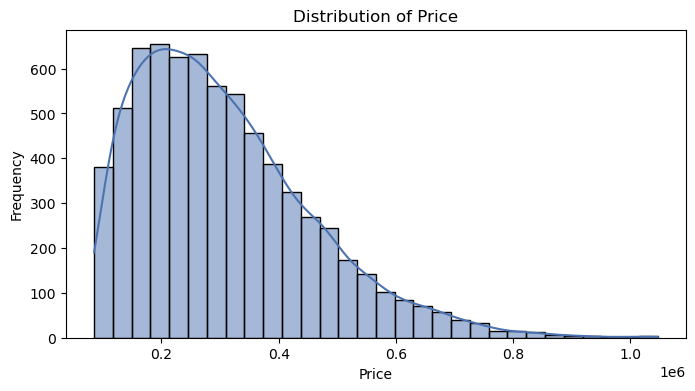

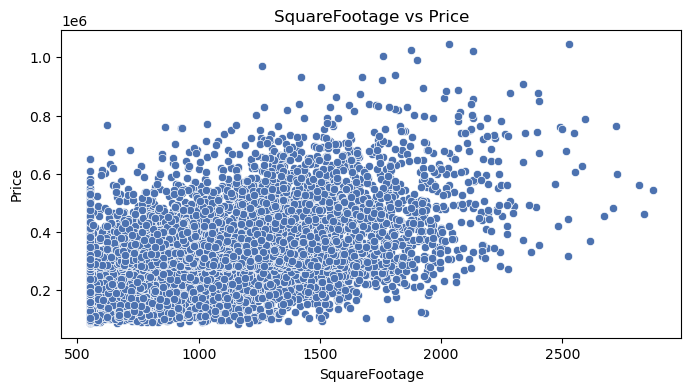

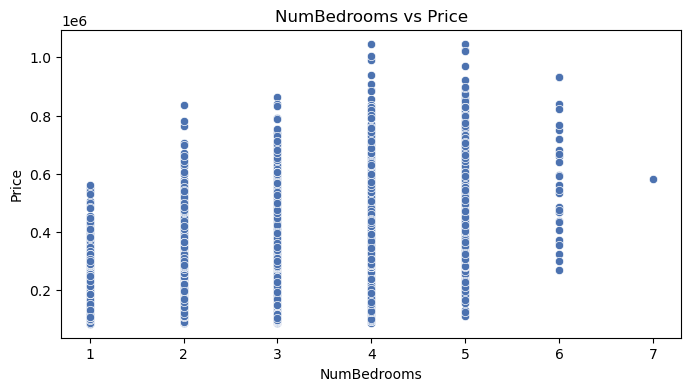

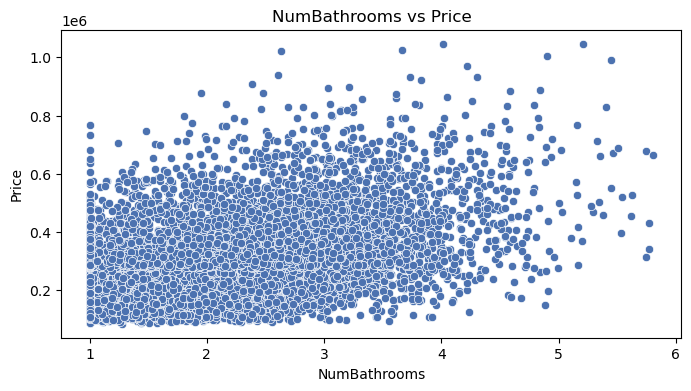

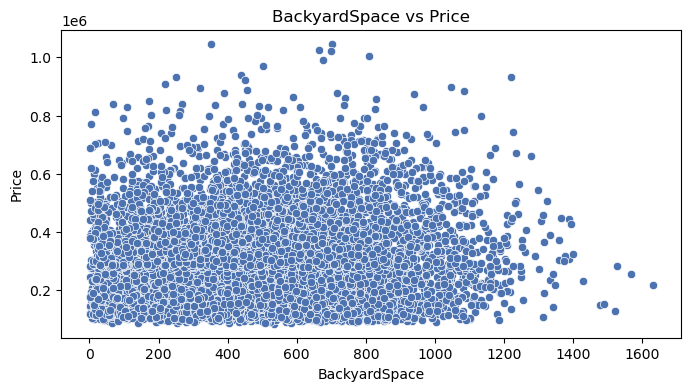

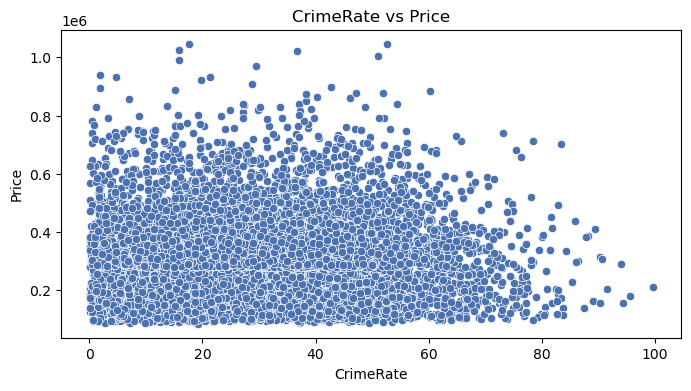

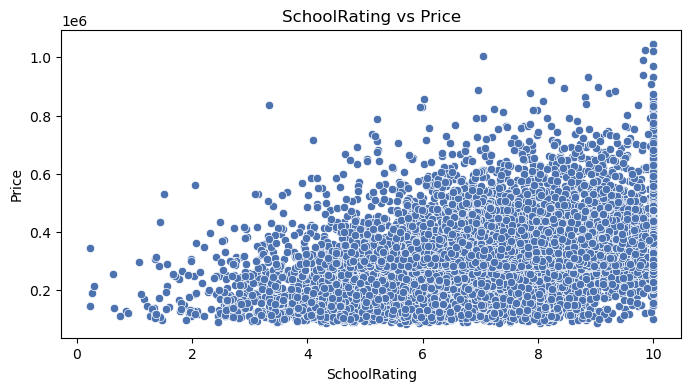

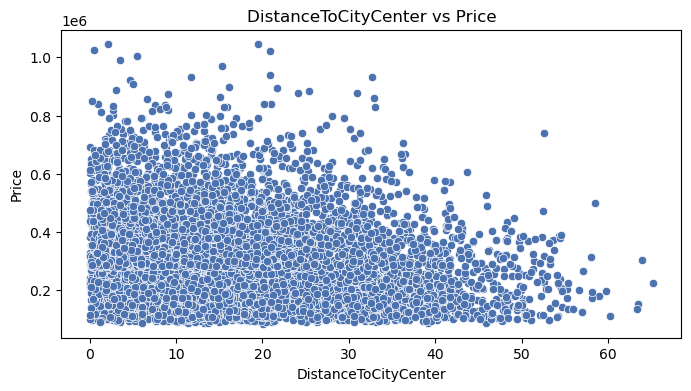

In [ ]:
# Generate visualizations to explore the data

import matplotlib.pyplot as plt
import seaborn as sns

# Function to create univariate visualizations
def plot_univariate(data, columns):
    """Plots the distribution of each column in the dataset."""
    for col in columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(data[col], kde=True, bins=30)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()

# Function to create bivariate visualizations
def plot_bivariate(data, independent_cols, dependent_col):
    """Plots the relationship between each independent variable and the dependent variable."""
    for col in independent_cols:
        plt.figure(figsize=(8, 4))
        sns.scatterplot(data=data, x=col, y=dependent_col)
        plt.title(f'{col} vs {dependent_col}')
        plt.xlabel(col)
        plt.ylabel(dependent_col)
        plt.show()

# Call the functions for visualizations
plot_univariate(data, independent_variables + [dependent_variable])
plot_bivariate(data, independent_variables, dependent_variable)

In [ ]:
# Split the data into training and testing sets

# Defining feature matrix (X) and target vector (y)
X = data[independent_variables]
y = data[dependent_variable]

# Splitting the dataset: 70% for training and 30% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Save the datasets
X_train.to_csv('train_features.csv', index=False)
X_test.to_csv('test_features.csv', index=False)
y_train.to_csv('train_labels.csv', index=False)
y_test.to_csv('test_labels.csv', index=False)

In [ ]:
# Initial Regression Model and Optimization

import statsmodels.api as sm
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Add a constant term and fit the initial regression model
X_train_const = sm.add_constant(X_train)
initial_model = sm.OLS(y_train, X_train_const).fit()

# Display the summary of the initial regression model
print("Initial Model Summary:")
print(initial_model.summary())

# Function to calculate Variance Inflation Factor (VIF)
def calculate_vif(data):
    return pd.DataFrame({
        "Variable": data.columns,
        "VIF": [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    })

# Calculate VIF for the initial model
initial_vif = calculate_vif(X_train_const)
print("Initial Variance Inflation Factor (VIF):")
print(initial_vif)

Initial Model Summary:
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.594
Model:                            OLS   Adj. R-squared:                  0.593
Method:                 Least Squares   F-statistic:                     1021.
Date:                Sat, 07 Dec 2024   Prob (F-statistic):               0.00
Time:                        18:46:37   Log-Likelihood:                -63181.
No. Observations:                4900   AIC:                         1.264e+05
Df Residuals:                    4892   BIC:                         1.264e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const    

In [77]:
# Function to calculate Variance Inflation Factor (VIF)
def calculate_vif(data):
    """
    Detect multicollinearity by calculating VIF for each feature.
    """
    vif = pd.DataFrame()
    vif["Variable"] = data.columns
    vif["VIF"] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif

# Check initial VIF values for independent variables
initial_vif = calculate_vif(X_train_const)
print("Initial Variance Inflation Factor (VIF):")
print(initial_vif)

Initial Variance Inflation Factor (VIF):
               Variable        VIF
0                 const  34.638380
1         SquareFootage   1.120258
2           NumBedrooms   1.193222
3          NumBathrooms   1.096021
4         BackyardSpace   1.018897
5             CrimeRate   1.043927
6          SchoolRating   1.387185
7  DistanceToCityCenter   1.065860


In [ ]:
# Start backward elimination to optimize the regression model
variables = list(X_train_const.columns)
p_thresh, vif_thresh = 0.05, 10  # Define thresholds for p-value and VIF

while True:
    # Fit the regression model with current variables
    model_sm = sm.OLS(y_train, X_train_const[variables]).fit()

    # Find the variable with the highest p-value or VIF
    max_p = model_sm.pvalues.max()
    max_vif = calculate_vif(X_train_const[variables])["VIF"].max()

    if max_p > p_thresh:  # Remove variable with highest p-value
        var_to_remove = model_sm.pvalues.idxmax()
        print(f"Dropping '{var_to_remove}' (p-value: {max_p:.3f})")
        variables.remove(var_to_remove)
    elif max_vif > vif_thresh:  # Remove variable with highest VIF
        var_to_remove = calculate_vif(X_train_const[variables]).sort_values("VIF", ascending=False).iloc[0]["Variable"]
        print(f"Dropping '{var_to_remove}' (VIF: {max_vif:.2f})")
        variables.remove(var_to_remove)
    else:  # Stop when all thresholds are met
        break

# Display optimized regression model summary
print("Optimized Model Summary:")
print(model_sm.summary())

Dropping 'CrimeRate' (p-value: 0.230)
Dropping 'SchoolRating' (p-value: 0.063)
Dropping 'const' (VIF: 24.98)
Optimized Model Summary:
                                 OLS Regression Results                                
Dep. Variable:                  Price   R-squared (uncentered):                   0.916
Model:                            OLS   Adj. R-squared (uncentered):              0.915
Method:                 Least Squares   F-statistic:                          1.062e+04
Date:                Sat, 07 Dec 2024   Prob (F-statistic):                        0.00
Time:                        18:47:02   Log-Likelihood:                         -63358.
No. Observations:                4900   AIC:                                  1.267e+05
Df Residuals:                    4895   BIC:                                  1.268e+05
Df Model:                           5                                                  
Covariance Type:            nonrobust                                     

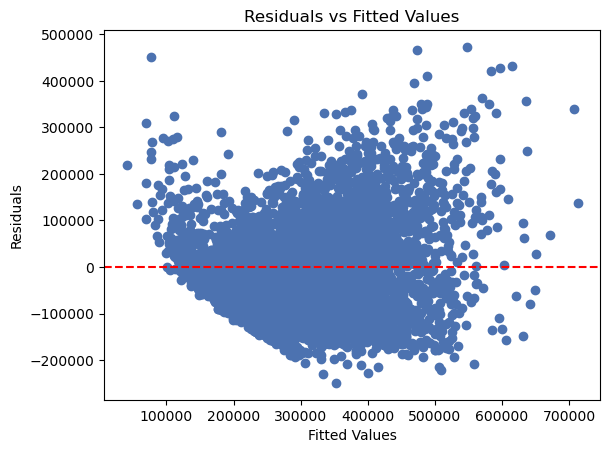

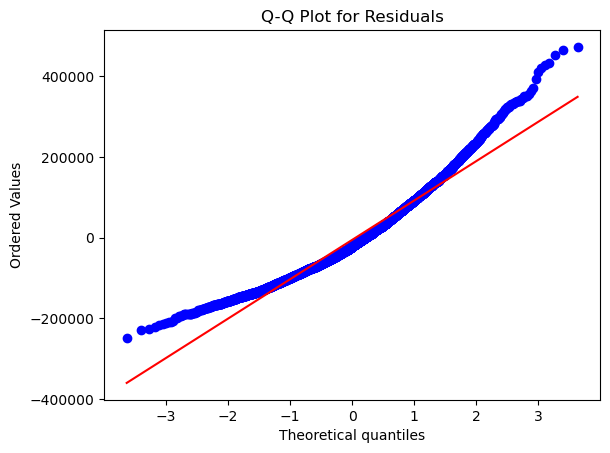

In [51]:
# Residuals and fitted values
residuals = model_sm.resid
fitted_values = model_sm.fittedvalues

# Residuals vs Fitted plot
plt.scatter(fitted_values, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

# Q-Q Plot for normality of residuals
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot for Residuals")
plt.show()

# Note: Ensure residuals are normally distributed and homoscedastic for model validity.

In [79]:
# Collect metrics from the optimized regression model
adjusted_r2 = model_sm.rsquared_adj
r2 = model_sm.rsquared
f_statistic = model_sm.fvalue
prob_f_statistic = model_sm.f_pvalue

# Create a DataFrame for coefficients and p-values
results_table = pd.DataFrame({
    "Variable": model_sm.params.index,
    "Coefficient": model_sm.params.values,
    "P-Value": model_sm.pvalues.values
})

# Append overall metrics to the table
metrics_table = pd.DataFrame({
    "Variable": ["Adjusted R²", "R²", "F-statistic", "Probability F-statistic"],
    "Coefficient": [adjusted_r2, r2, f_statistic, prob_f_statistic],
    "P-Value": [None, None, None, None]
})

final_table = pd.concat([results_table, metrics_table], ignore_index=True)
print("Optimized Regression Results:")
print(final_table)

Optimized Regression Results:
                  Variable   Coefficient P-Value
0            SquareFootage    130.126950     0.0
1              NumBedrooms  42185.269171     0.0
2             NumBathrooms  45890.496415     0.0
3            BackyardSpace    -37.595887     0.0
4     DistanceToCityCenter  -1635.424818     0.0
5              Adjusted R²      0.915481    None
6                       R²      0.915568    None
7              F-statistic  10616.067594    None
8  Probability F-statistic      0.000000    None


In [80]:
# Generate regression equation
equation = "Price = "
for i, row in results_table.iterrows():
    if row["Variable"] != "const":
        equation += f"{row['Coefficient']:.2f} * {row['Variable']} + "
    else:
        equation += f"{row['Coefficient']:.2f} + "

# Remove trailing "+ " and display the equation
equation = equation.rstrip(" + ")
print("Regression Equation:")
print(equation)

Regression Equation:
Price = 130.13 * SquareFootage + 42185.27 * NumBedrooms + 45890.50 * NumBathrooms + -37.60 * BackyardSpace + -1635.42 * DistanceToCityCenter


In [81]:
# Compare metrics before and after optimization
before_metrics = {
    "Metric": ["R²", "Adjusted R²", "F-statistic", "Probability F-statistic"],
    "Before Optimization": [initial_model.rsquared, initial_model.rsquared_adj, initial_model.fvalue, initial_model.f_pvalue]
}
after_metrics = {
    "Metric": ["R²", "Adjusted R²", "F-statistic", "Probability F-statistic"],
    "After Optimization": [model_sm.rsquared, model_sm.rsquared_adj, model_sm.fvalue, model_sm.f_pvalue]
}

# Create a styled summary table for comparison
summary_table = pd.DataFrame(before_metrics).merge(pd.DataFrame(after_metrics), on="Metric")
styled_table = (
    summary_table.style
    .set_caption("Before and After Optimization Metrics")
    .format({"Before Optimization": "{:.3f}", "After Optimization": "{:.3f}"})
    .hide_index()
    .set_table_styles(
        [{"selector": "caption", "props": [("font-size", "16px"), ("text-align", "center")]}]
    )
)
styled_table

C:\Users\MayCooperStation\AppData\Local\Temp\ipykernel_29324\2927892008.py:17: FutureWarning: this method is deprecated in favour of `Styler.hide(axis="index")`
  .hide_index()


Metric,Before Optimization,After Optimization
R²,0.594,0.916
Adjusted R²,0.593,0.915
F-statistic,1021.367,10616.068
Probability F-statistic,0.000,0.000


In [ ]:
# Calculate MSE on the training dataset
train_predictions = model_sm.predict(X_train_const[variables])
train_mse = mean_squared_error(y_train, train_predictions)
print(f"Mean Squared Error (MSE) on Training Data: {train_mse}")

Mean Squared Error (MSE) on Training Data: 9966706428.760166


In [ ]:
# Evaluate Model on Test Data

from sklearn.metrics import mean_squared_error

# Use only the variables from the optimized model
X_test_optimized = X_test[variables]

# Add a constant term to match the training data
X_test_const = sm.add_constant(X_test_optimized, has_constant="add")

# Align test dataset columns with the model parameters
X_test_const = X_test_const[model_sm.params.index]

# Make predictions on the test data
test_predictions = model_sm.predict(X_test_const)

# Calculate MSE for the test dataset
test_mse = mean_squared_error(y_test, test_predictions)
print(f"Test Data MSE: {test_mse:.2f}")

# Calculate RMSE for the test dataset
test_rmse = test_mse ** 0.5
print(f"Test Data RMSE: {test_rmse:.2f}")

# Compare RMSE to the average price in the test data
mean_test_price = y_test.mean()
rmse_percentage = (test_rmse / mean_test_price) * 100
print(f"Average House Price in Test Data: {mean_test_price:.2f}")
print(f"RMSE as % of Average Price: {rmse_percentage:.2f}%")

Test Data MSE: 9825425331.64
Test Data RMSE: 99123.28
Average House Price in Test Data: 304258.77
RMSE as % of Average Price: 32.58%
